## Bias : Errors due to wrong assumption 
## Variance : small change in data set cause major change in model this kind of sensitivity towards small changes is reffered as variance.

# Overfitting: 
- model becomes complex
- low bias, high variance

# Underfitting
- model becomes too simple
- high bias, low variance 

# Regularization
- to genearlize or simplify the Linear Regression
## Lasso Regularization (L1 regularization)
- (1/2m) S_i_m(h(x_i) - y_i)^2 + lambda S_j_n|A_j|
- so model get penalized by according to number of feature an its slope gets shifted towards x axis
- it could reduce a feature cofficient to 0 thereby facilitates feature selection.

## Ridge Regularization (L2 regularization)
- (1/2m) S_i_m(h(x_i) - y_i)^2 + lambda S_j_n(A_j)^2
- so model get penalized by according to number of feature an its slope gets shifted towards x axis

In [11]:
# Lasso Regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import seaborn as sns
from sklearn.linear_model import LassoCV

In [2]:
insurance_data = pd.read_csv("1_insurance.csv")
X = insurance_data.drop(columns=["charges"])
y= insurance_data["charges"]

# numeric feature engneering
X["smoker"] = X["smoker"].map({"yes" : 1, "no" : 2 })
X["sex"] = X["sex"].map({"female" : 1, "male" : 2})

# one hot encoding
X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

# New Feature generations
X["bmi_smoker"] = X["bmi"] * X["smoker"]
X["age_smoker"] = X["age"] * X["smoker"]

X

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_smoker,age_smoker
0,19,1,27.900,0,1,0,0,1,27.90,19
1,18,2,33.770,1,2,0,1,0,67.54,36
2,28,2,33.000,3,2,0,1,0,66.00,56
3,33,2,22.705,0,2,1,0,0,45.41,66
4,32,2,28.880,0,2,1,0,0,57.76,64
...,...,...,...,...,...,...,...,...,...,...
1333,50,2,30.970,3,2,1,0,0,61.94,100
1334,18,1,31.920,0,2,0,0,0,63.84,36
1335,18,1,36.850,0,2,0,1,0,73.70,36
1336,21,1,25.800,0,2,0,0,1,51.60,42


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
X_train

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_smoker,age_smoker
1069,54,1,31.900,1,2,0,1,0,63.800,108
476,24,2,28.500,0,1,0,0,0,28.500,24
157,18,2,25.175,0,1,0,0,0,25.175,18
16,52,1,30.780,1,2,0,0,0,61.560,104
1072,21,2,31.255,0,2,1,0,0,62.510,42
...,...,...,...,...,...,...,...,...,...,...
1095,18,1,31.350,4,2,0,0,0,62.700,36
1130,39,1,23.870,5,2,0,1,0,47.740,78
1294,58,2,25.175,0,2,0,0,0,50.350,116
860,37,1,47.600,2,1,0,0,1,47.600,37


In [15]:
# Model Training

alpha_array=[]
mse_array=[]
least_mse= float('inf')
best_alpha=-1
for a in np.arange(0.01, 50, 0.5):
    alpha_array.append(a)
    model_lasso = Lasso(alpha=a)
    model_lasso.fit(X_train, y_train)
    
    y_pred = model_lasso.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_array.append(mse)
    if (mse<least_mse):
        least_mse = mse
        best_alpha = a
        r2 = r2_score(y_test, y_pred)
        
    
print("Least Mean Squared Error :",least_mse)
print("Best alpha value :", best_alpha)
print(f"R2 Score : {r2}")

Least Mean Squared Error : 23825984.05598082
Best alpha value : 0.01
R2 Score : 0.834571191213157


<Axes: >

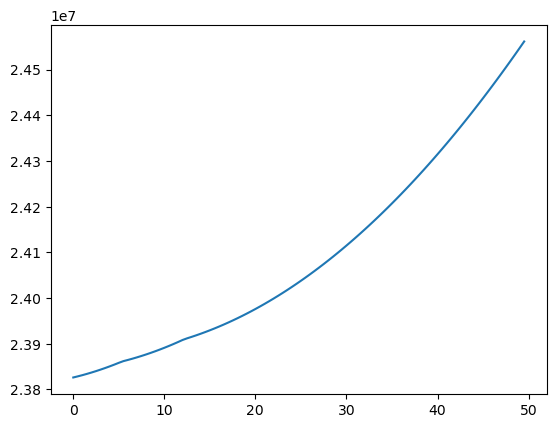

In [5]:
sns.lineplot(x=alpha_array, y=mse_array)

In [12]:
# Lasso CV
alpha_array = np.arange(0.01,50,0.5)
model_lasso_cv = LassoCV(
    alphas=alpha_array,
    cv=5,
    max_iter=1000,
    random_state=42
)

model_lasso_cv.fit(X_train, y_train)

print(f"Best alpha value for LassoCV = {model_lasso_cv.alpha_}" )

y_pred = model_lasso_cv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Square Error : {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R2 Score : {r2}")

Best alpha value for LassoCV = 15.51
Mean Square Error : 23933254.804548405
R2 Score : 0.8338263878878668


# ELasticNet
- It is the combination of both lasso and ridge regression we decided how much percent of penalty of which category we want.
- (1/2m) S_i_n(h(x_i) - y(i)^2) + P . L.S_i_m(|T_j|) + (1 - P). L.S_i_m((T.j)^2)